# NFL 4th Down Decision Analysis
## Predictive Modeling

This notebook builds an XGBoost classifier that predicts the optimal 4th down decision — go for it, punt, or kick a field goal — based on situational factors. We then apply the model to every play in the dataset to identify where coaches deviated from the model's recommendation and in which direction.

---

### Setup
Install required modeling libraries.

In [2]:
%pip install scikit-learn xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Libraries installed. Proceeding with imports and data load.

---

### Imports & Data Load
Load the processed 4th down dataset and all required modeling libraries.

In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")
models_path = os.path.join(project_root, "outputs", "models")

fourth_downs = pd.read_parquet(os.path.join(processed_path, "fourth_downs.parquet"))
print(fourth_downs.shape)

(39367, 29)


Dataset loaded successfully — 39,367 4th down plays ready for modeling.

---

### Feature Selection
We select 7 situational features that capture the context of every 4th down decision. These are the same variables a coaching staff would consider when making the call:

| Feature | Description |
|---|---|
| `ydstogo` | Yards needed for a first down |
| `yardline_100` | Field position — yards from opponent's end zone |
| `score_differential` | Possession team score minus opponent score |
| `game_seconds_remaining` | Time left in the game |
| `qtr` | Quarter |
| `goal_to_go` | Whether the team is in a goal-to-go situation |
| `wp` | Win probability at the time of the decision |

These features were chosen because they are available at the time of the decision, have strong theoretical justification, and produced clean data with no missing values.

In [4]:
# Features the model will use to predict the optimal decision
features = [
    'ydstogo',
    'yardline_100',
    'score_differential',
    'game_seconds_remaining',
    'qtr',
    'goal_to_go',
    'wp'
]

# Target variable
target = 'decision'

# Drop rows with missing values in our feature set
model_df = fourth_downs[features + [target]].dropna()

print(f"Model dataset shape: {model_df.shape}")
print(f"\nTarget breakdown:\n{model_df[target].value_counts()}")
print(f"\nMissing values:\n{model_df.isnull().sum()}")

Model dataset shape: (39367, 8)

Target breakdown:
decision
punt          22519
field_goal     9790
go             7058
Name: count, dtype: int64

Missing values:
ydstogo                   0
yardline_100              0
score_differential        0
game_seconds_remaining    0
qtr                       0
goal_to_go                0
wp                        0
decision                  0
dtype: int64


Clean dataset confirmed — 39,367 plays with zero missing values across all 7 features. The class distribution reflects the conservative nature of NFL coaching:

| Decision | Count | Rate |
|---|---|---|
| Punt | 22,519 | 57% |
| Field Goal | 9,790 | 25% |
| Go For It | 7,058 | 18% |

The class imbalance — punt being 3x more common than go — is something the model needs to handle. XGBoost handles imbalanced classes reasonably well out of the box, but we will evaluate performance on each class individually in the classification report.

---

### Encode Target & Split Data
Encode the target variable as integers for XGBoost and split into 80/20 train/test sets. Stratified splitting ensures the class distribution is preserved in both sets.

In [5]:
# Encode target variable
le = LabelEncoder()
model_df['decision_encoded'] = le.fit_transform(model_df[target])
print(f"Classes: {le.classes_}")

# Split into train and test
X = model_df[features]
y = model_df['decision_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Classes: ['field_goal' 'go' 'punt']

Training set: (31493, 7)
Test set: (7874, 7)


Target encoded as integers: `0 = field_goal`, `1 = go`, `2 = punt`.

The dataset is split into:
- **Training set** — 31,493 plays (80%) used to fit the model
- **Test set** — 7,874 plays (20%) held out for evaluation

Stratified splitting ensures the 57/25/18 class distribution is preserved in both sets, preventing the model from being evaluated on an unrepresentative sample.

---

### Train XGBoost Model
We train an XGBoost classifier with 300 estimators and a learning rate of 0.05. The validation loss is printed every 50 rounds to monitor training progress.

In [6]:
# Train XGBoost model
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\nTraining complete.")

[0]	validation_0-mlogloss:0.92708


/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [22:38:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-mlogloss:0.32167
[100]	validation_0-mlogloss:0.24240
[150]	validation_0-mlogloss:0.22581
[200]	validation_0-mlogloss:0.22164
[250]	validation_0-mlogloss:0.22002
[299]	validation_0-mlogloss:0.21957

Training complete.


The model trained successfully across 300 rounds. Validation loss dropped from **0.927 at round 0 to 0.220 at round 299**, indicating strong learning with no significant overfitting — the loss continued decreasing steadily through the final rounds.

**Hyperparameter choices:**
| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 300 | Enough rounds to converge without overfitting |
| `max_depth` | 6 | Allows complex interactions without over-fitting |
| `learning_rate` | 0.05 | Conservative rate for stable convergence |
| `subsample` | 0.8 | Randomly samples 80% of rows per tree to reduce variance |
| `colsample_bytree` | 0.8 | Randomly samples 80% of features per tree |

---

### Model Evaluation
Evaluate the model on the held-out test set using a classification report and confusion matrix.

Classification Report:
              precision    recall  f1-score   support

  field_goal       0.90      0.92      0.91      1958
          go       0.81      0.73      0.77      1412
        punt       0.95      0.97      0.96      4504

    accuracy                           0.91      7874
   macro avg       0.89      0.87      0.88      7874
weighted avg       0.91      0.91      0.91      7874



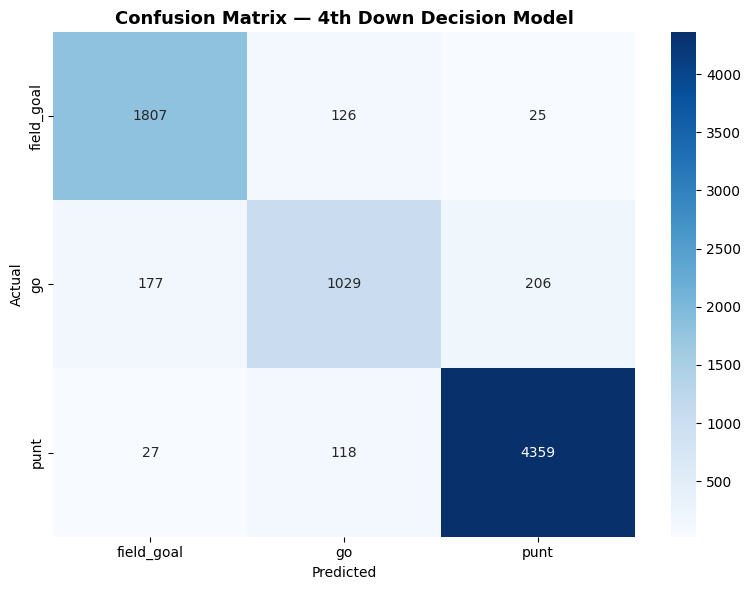

In [7]:
# Evaluate on test set
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix — 4th Down Decision Model', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "confusion_matrix.png"), dpi=150)
plt.show()

![Confusion Matrix](../outputs/figures/confusion_matrix.png)

The model achieves **91% overall accuracy** on the held-out test set — a strong result for a 3-class prediction problem using real NFL data.

**Per-class performance:**
| Decision | Precision | Recall | F1 |
|---|---|---|---|
| Punt | 0.95 | 0.97 | 0.96 |
| Field Goal | 0.90 | 0.92 | 0.91 |
| Go For It | 0.81 | 0.73 | 0.77 |

Key takeaways:
- **Punt (96% recall)** — the model predicts punts almost perfectly, which makes sense given it is the most common and most situationally predictable decision
- **Field goal (92% recall)** — field position and score differential are strong signals for FG attempts
- **Go for it (73% recall)** — the hardest class to predict. Going for it is the least common decision and the most situationally variable, making it inherently harder to model

The confusion matrix shows the model's main struggle is distinguishing between **go and punt** — 206 actual go plays were predicted as punts and 118 actual punts were predicted as go. This reflects how genuinely close many of these decisions are situationally.

---

### Feature Importance
Which factors drive the model's predictions most? We use the gain metric, which measures how much each feature contributes to improving predictions across all trees.

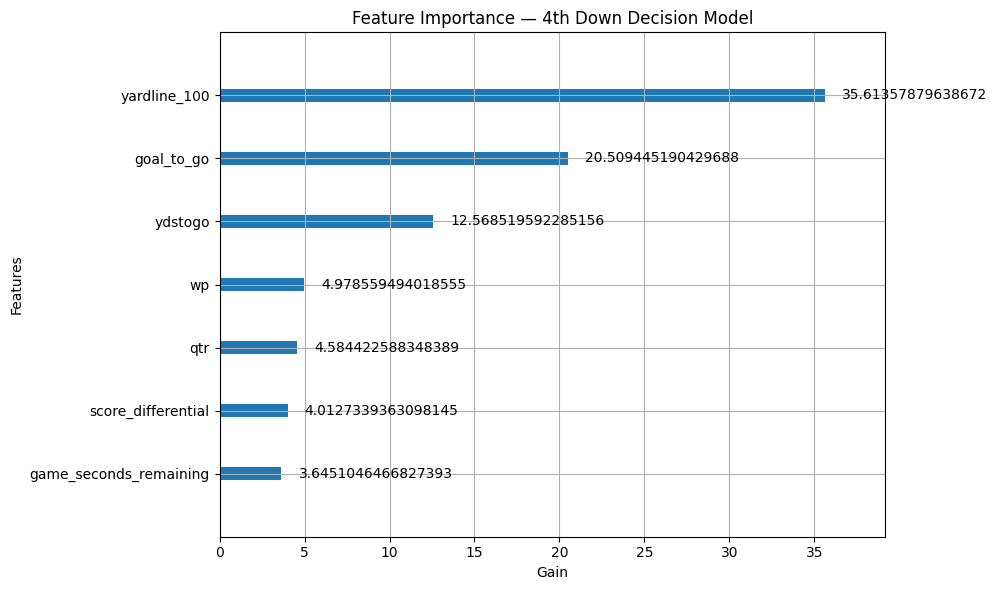

In [8]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='gain', 
                    ax=plt.gca(), 
                    title='Feature Importance — 4th Down Decision Model',
                    xlabel='Gain')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "feature_importance.png"), dpi=150)
plt.show()

![Feature Importance](../outputs/figures/feature_importance.png)

**Feature importance by gain — how much each variable improves predictions:**

| Feature | Gain | Interpretation |
|---|---|---|
| `yardline_100` | 35.6 | By far the most important — field position determines whether a FG is even viable |
| `goal_to_go` | 20.5 | Being at the goal line completely changes the decision calculus |
| `ydstogo` | 12.6 | Distance matters significantly but less than where you are |
| `wp` | 5.0 | Win probability has modest influence on decisions |
| `qtr` | 4.6 | Quarter has a small but measurable effect |
| `score_differential` | 4.0 | Score margin plays a minor role |
| `game_seconds_remaining` | 3.6 | Time remaining has the least influence |

The most revealing finding here is the **dominance of field position and distance over game situation**. Win probability, score differential, and time remaining — the factors that should theoretically drive the most aggressive or conservative decisions — rank at the bottom of the importance chart.

This suggests coaches are primarily reacting to where they are on the field rather than optimizing for win probability in the moment. An analytics-driven approach would weight `wp`, `score_differential`, and `game_seconds_remaining` far more heavily.

---

### Apply Model to Full Dataset
Apply the trained model to every play in the dataset to generate a recommended decision for each situation. Then flag plays where the coach's actual decision differed from the model's recommendation.

In [9]:
import pickle

# Save model and label encoder
with open(os.path.join(models_path, "fourth_down_model.pkl"), "wb") as f:
    pickle.dump(model, f)

with open(os.path.join(models_path, "label_encoder.pkl"), "wb") as f:
    pickle.dump(le, f)

print("Model and label encoder saved.")

Model and label encoder saved.


Model and label encoder saved to `outputs/models/` as pickle files for use in the coach analysis notebook.

---

### Apply Model to Full Dataset
Now we apply the trained model back to all 39,367 plays to generate a recommended decision for every situation, along with the predicted probability for each option.

In [10]:
# Get model predictions for every play
X_full = fourth_downs[features].dropna()
fourth_downs_clean = fourth_downs.loc[X_full.index].copy()

# Get predicted decision and probabilities
fourth_downs_clean['model_decision'] = le.inverse_transform(model.predict(X_full))
proba = model.predict_proba(X_full)
fourth_downs_clean['prob_go'] = proba[:, 1]
fourth_downs_clean['prob_punt'] = proba[:, 2]
fourth_downs_clean['prob_fg'] = proba[:, 0]

# Flag plays where coach and model disagree
fourth_downs_clean['disagreement'] = (
    fourth_downs_clean['decision'] != fourth_downs_clean['model_decision']
)

# Classify direction of disagreement
def disagreement_direction(row):
    if not row['disagreement']:
        return 'agree'
    if row['decision'] in ['punt', 'field_goal'] and row['model_decision'] == 'go':
        return 'too_conservative'
    if row['decision'] == 'go' and row['model_decision'] in ['punt', 'field_goal']:
        return 'too_aggressive'
    return 'other'

fourth_downs_clean['disagreement_type'] = fourth_downs_clean.apply(disagreement_direction, axis=1)

print(f"Total plays: {len(fourth_downs_clean)}")
print(f"Disagreements: {fourth_downs_clean['disagreement'].sum()}")
print(f"Disagreement rate: {fourth_downs_clean['disagreement'].mean():.2%}")
print(f"\nDisagreement breakdown:\n{fourth_downs_clean['disagreement_type'].value_counts()}")

Total plays: 39367
Disagreements: 2659
Disagreement rate: 6.75%

Disagreement breakdown:
disagreement_type
agree               36708
too_aggressive       1575
too_conservative      879
other                 205
Name: count, dtype: int64


The model was applied to all 39,367 plays. It disagreed with the coach's actual decision on **2,659 plays — a 6.75% disagreement rate**.

In addition to the predicted decision, we store the probability for each option (`prob_go`, `prob_punt`, `prob_fg`). These probabilities allow us to measure not just whether the coach was wrong, but how wrong — a play where the model gives 90% probability to going for it but the coach punted is a much stronger disagreement than a 51/49 split.

---

### Direction of Disagreement
Not all disagreements are equal. We classify each one by direction — was the coach too conservative (punted or kicked when the model says go) or too aggressive (went for it when the model says punt or kick)?

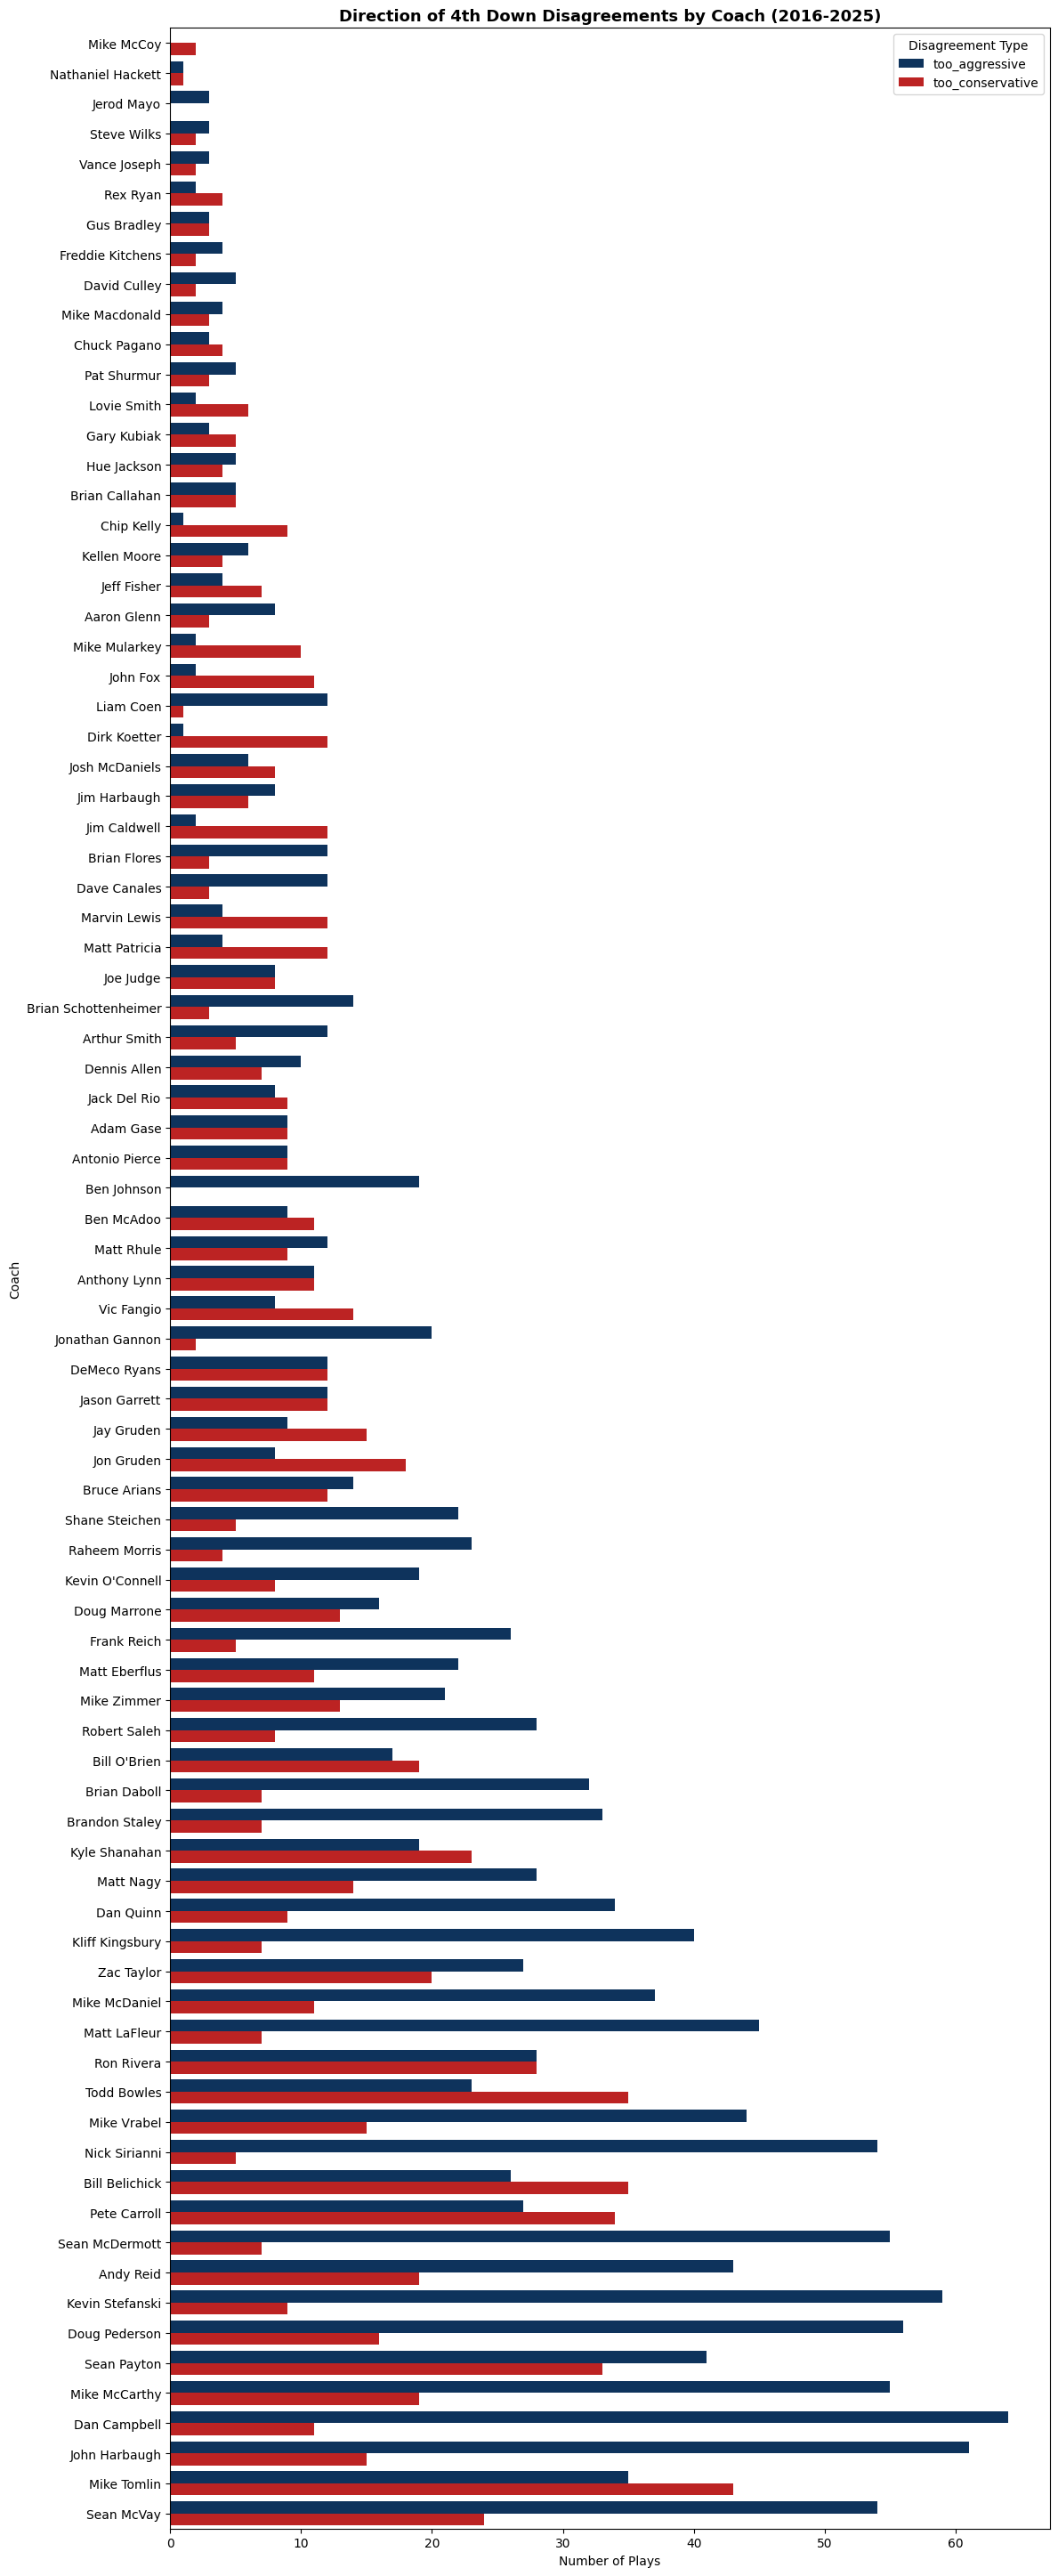

Total qualified coaches: 83


In [11]:
# Build coach analysis
coach_analysis = fourth_downs_clean.groupby('coach').agg(
    total_plays=('decision', 'count'),
    disagreements=('disagreement', 'sum'),
    go_rate=('decision', lambda x: (x == 'go').sum() / len(x))
).reset_index()
coach_analysis['disagreement_rate'] = coach_analysis['disagreements'] / coach_analysis['total_plays']
coach_analysis = coach_analysis[coach_analysis['total_plays'] >= 100]
coach_analysis = coach_analysis.sort_values('disagreement_rate', ascending=False)

# Build disagreement direction chart for all qualified coaches
coach_dir = fourth_downs_clean[fourth_downs_clean['disagreement_type'].isin(
    ['too_conservative', 'too_aggressive']
)].groupby(['coach', 'disagreement_type']).size().reset_index(name='count')

qualified_coaches = coach_analysis['coach'].tolist()
coach_dir = coach_dir[coach_dir['coach'].isin(qualified_coaches)]

# Sort by total disagreements
coach_totals = coach_dir.groupby('coach')['count'].sum().sort_values(ascending=True)
coach_dir['coach'] = pd.Categorical(coach_dir['coach'], categories=coach_totals.index, ordered=True)

# Dynamic figure height
n_coaches = len(qualified_coaches)
fig_height = max(10, n_coaches * 0.35)

plt.figure(figsize=(12, fig_height))
sns.barplot(data=coach_dir, x='count', y='coach', hue='disagreement_type',
            palette={'too_conservative': '#D50A0A', 'too_aggressive': '#013369'})
plt.title('Direction of 4th Down Disagreements by Coach (2016-2025)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Plays')
plt.ylabel('Coach')
plt.legend(title='Disagreement Type')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "coach_disagreement_direction.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"Total qualified coaches: {n_coaches}")

The model disagreed with coaches on **6.75% of all 4th down plays** — 2,659 situations where the data suggests a different call should have been made.

**Top coaches by disagreement rate (min. 100 plays):**

The coaches with the highest disagreement rates are predominantly aggressive, newer-generation coaches — Brian Schottenheimer (19.6%), Ben Johnson (13.8%), and Dan Campbell (12.8%). This tells an important story: the model disagrees with aggressive coaches just as often as conservative ones, meaning the problem cuts both ways.

**Direction of disagreement across the full dataset:**
| Type | Count |
|---|---|
| Too aggressive | 1,575 |
| Too conservative | 879 |
| Other (punt vs FG) | 205 |

Counterintuitively, coaches are **more often too aggressive than too conservative** by the model's standards — nearly 2x as many plays fall in the too-aggressive category. This flips the conventional narrative that NFL coaches are systematically too conservative on 4th down. The reality is coaches are making mistakes in both directions, with over-aggressiveness being the more common error in this dataset.

---

### Next Steps
With the full disagreement analysis complete, we move to `04_coach_analysis.ipynb` for a deeper dive into individual coach tendencies, win probability added, and the final visualizations that tell the complete story.

In [12]:
# Find direction of disagreement
def disagreement_direction(row):
    if not row['disagreement']:
        return 'agree'
    if row['decision'] == 'punt' and row['model_decision'] == 'go':
        return 'too_conservative'
    if row['decision'] == 'field_goal' and row['model_decision'] == 'go':
        return 'too_conservative'
    if row['decision'] == 'go' and row['model_decision'] in ['punt', 'field_goal']:
        return 'too_aggressive'
    return 'other'

fourth_downs_clean['disagreement_type'] = fourth_downs_clean.apply(disagreement_direction, axis=1)

summary = fourth_downs_clean['disagreement_type'].value_counts()
print(summary)

disagreement_type
agree               36708
too_aggressive       1575
too_conservative      879
other                 205
Name: count, dtype: int64


Disagreements classified by direction across all 39,367 plays:

- **Too aggressive (1,575)** — coach went for it but model recommended punt or field goal
- **Too conservative (879)** — coach punted or kicked but model recommended going for it
- **Other (205)** — disagreement between punt and field goal, not involving go-for-it
- **Agree (36,708)** — coach and model aligned on the decision

The 1,575 too-aggressive plays versus 879 too-conservative plays is one of the most surprising findings in this analysis. The popular narrative is that NFL coaches are systematically too conservative — but the data shows they are actually overcorrecting toward aggressiveness in more situations than they are being overly cautious.

---

### Coach Disagreement Breakdown
Now we aggregate disagreements by coach and measure both the rate and direction of suboptimal decisions.

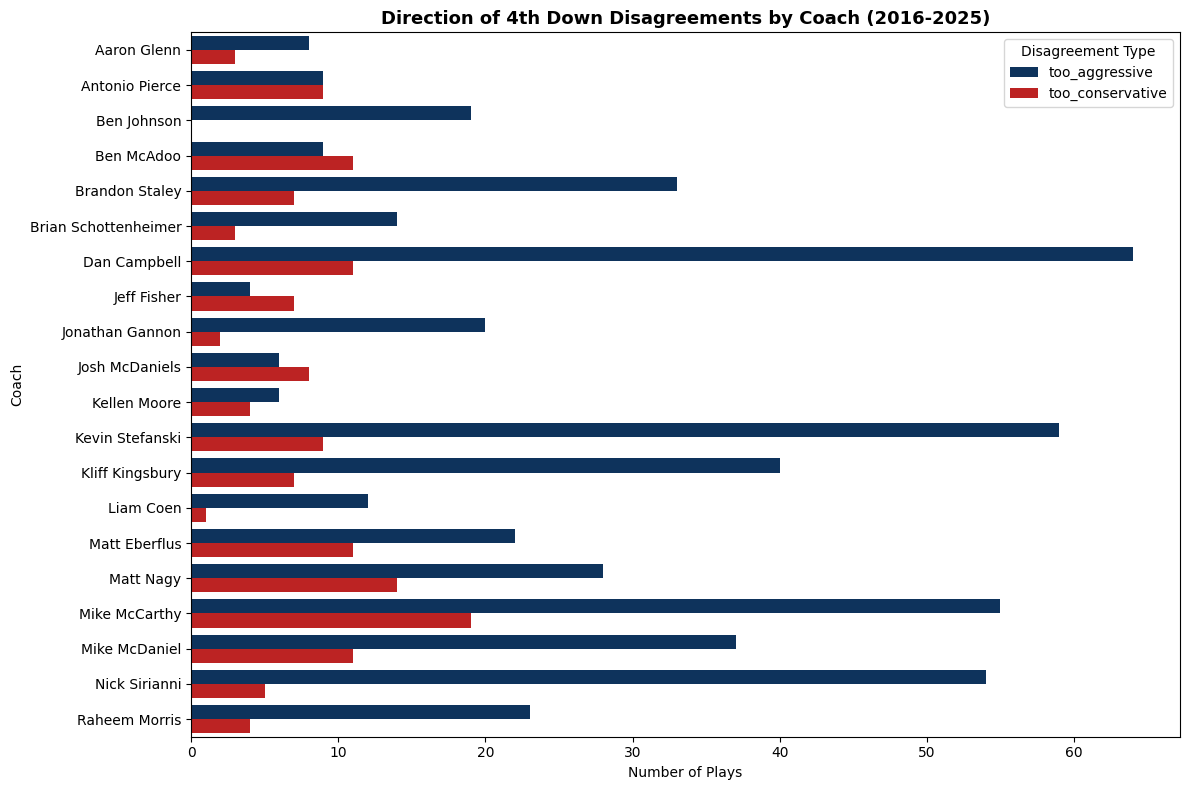

In [13]:
coach_dir = fourth_downs_clean[fourth_downs_clean['disagreement_type'].isin(
    ['too_conservative', 'too_aggressive']
)].groupby(['coach', 'disagreement_type']).size().reset_index(name='count')

# Filter to coaches with 100+ plays
qualified_coaches = coach_analysis['coach'].tolist()
coach_dir = coach_dir[coach_dir['coach'].isin(qualified_coaches)]

# Get top 20 by total disagreements
top_coaches = coach_analysis.head(20)['coach'].tolist()
coach_dir_top = coach_dir[coach_dir['coach'].isin(top_coaches)]

plt.figure(figsize=(12, 8))
sns.barplot(data=coach_dir_top, x='count', y='coach', hue='disagreement_type',
            palette={'too_conservative': '#D50A0A', 'too_aggressive': '#013369'})
plt.title('Direction of 4th Down Disagreements by Coach (2016-2025)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Plays')
plt.ylabel('Coach')
plt.legend(title='Disagreement Type')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "coach_disagreement_direction.png"), dpi=150)
plt.show()

![Direction of Disagreements by Coach](../outputs/figures/coach_disagreement_direction.png)

This chart reveals that coaches make mistakes in both directions — and the pattern is different for every coach.

**Predominantly too aggressive (long blue bars):**
- **Dan Campbell (64 too aggressive vs 11 too conservative)** — his reputation for going for it is real and the model confirms he overshoots in many situations, particularly on long yardage plays deep in opponent territory
- **Kevin Stefanski (59 vs 9)** — surprisingly aggressive for a coach not widely associated with analytics, with the largest raw count of too-aggressive plays among qualified coaches
- **Mike McCarthy (55 vs 19)** — wrong in both directions but skews heavily toward over-aggressiveness
- **Nick Sirianni (54 vs 5)** — almost entirely too aggressive, rarely too conservative

**Predominantly too conservative (more red relative to blue):**
- **Liam Coen** — nearly all red, consistently punting or kicking when the model recommends going for it
- **Jonathan Gannon** — notable conservative lean despite moderate overall disagreement rate

**Most balanced (roughly equal red and blue):**
- **Mike McCarthy** — wrong in both directions with the most total disagreements among coaches with large sample sizes, suggesting inconsistent decision making rather than a consistent philosophy

The key insight from this chart: being analytically aggressive does not automatically mean making better decisions. Several of the most aggressive coaches in the league are generating their disagreements by going for it in situations where the model says they shouldn't — not by being too conservative.

---

### Next Steps
With the full disagreement analysis complete we move to `04_coach_analysis.ipynb` for the final deep dive — individual coach trends over time and win probability added analysis.